## Series temporales - Electricidad

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [77]:
# ── Carga de datos ─────────────────────────────────────────────────────────────
data = pd.read_excel(
    r"electricidad.xlsx",
    sheet_name="consumo_electrico",
    index_col="periodo",
    parse_dates=True
)

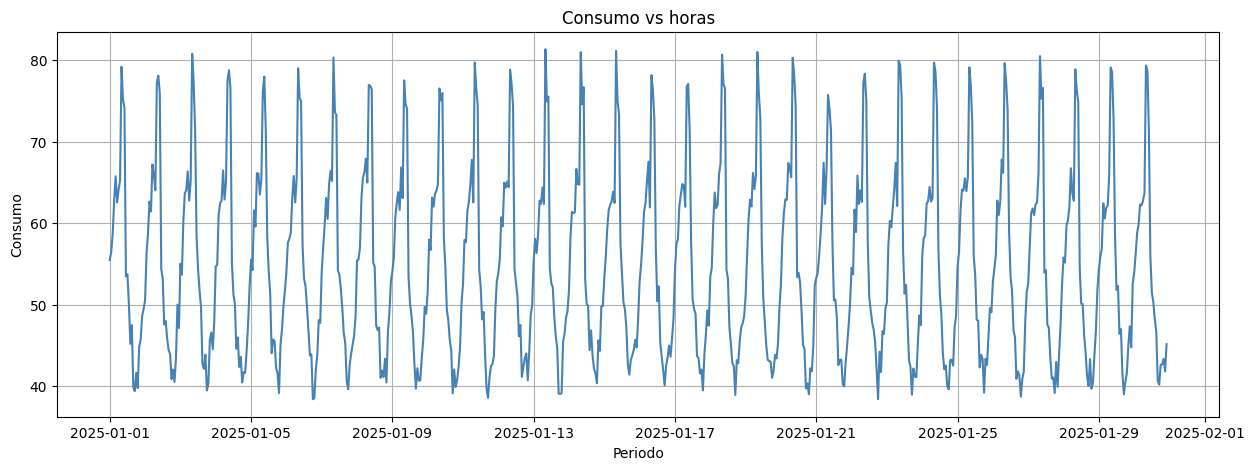

In [78]:
# ── Visualización de la serie temporal ────────────────────────────────────────
plt.figure(figsize=(15, 5))
plt.plot(data.index, data["consumo"], color="steelblue")
plt.title("Consumo vs horas")
plt.xlabel("Periodo")
plt.ylabel("Consumo")
plt.grid()
plt.show()

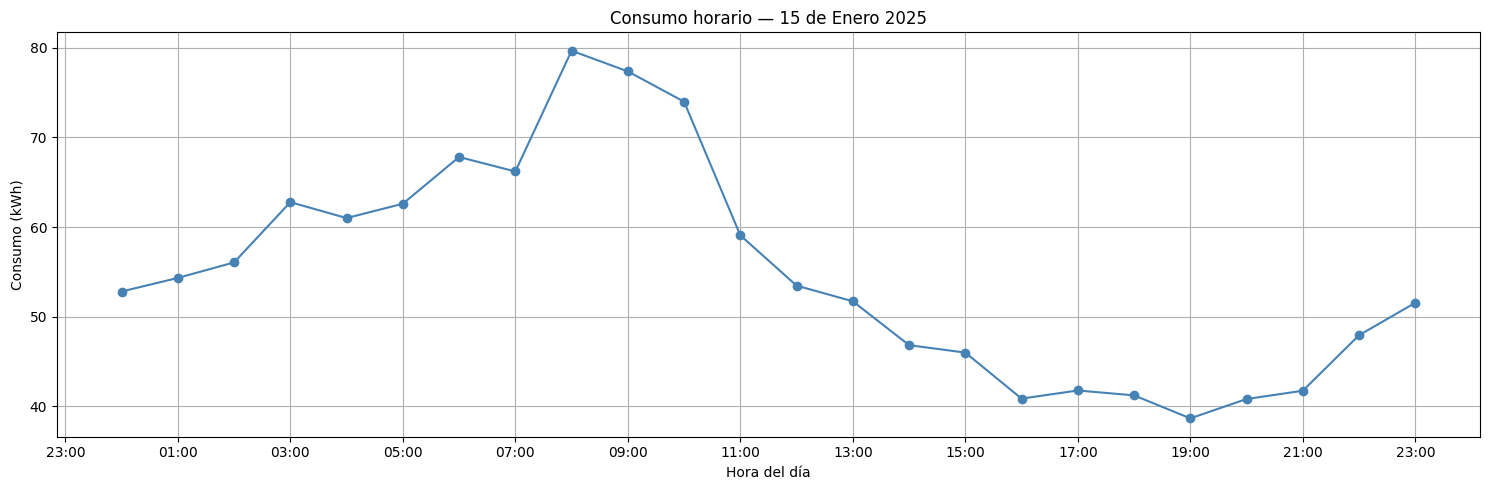

In [79]:
# ── Visualización de la serie temporal ────────────────────────────────────────
un_dia = data.loc["2025-01-26"]

plt.figure(figsize=(15, 5))
plt.plot(un_dia.index, un_dia["consumo"], color="steelblue", marker="o")

plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.title("Consumo horario — 15 de Enero 2025")
plt.xlabel("Hora del día")
plt.ylabel("Consumo (kWh)")
plt.grid()
plt.tight_layout()
plt.show()

- Se da tendencia: sube y baja
- Se da estacionalidad --> Se repiten patrones
- No hay días vacios

In [80]:
# ── Separación train / test ───────────────────────────────────────────────────
train_size = int(len(data) * 0.8)
train = data.iloc[:train_size]
test  = data.iloc[train_size:]

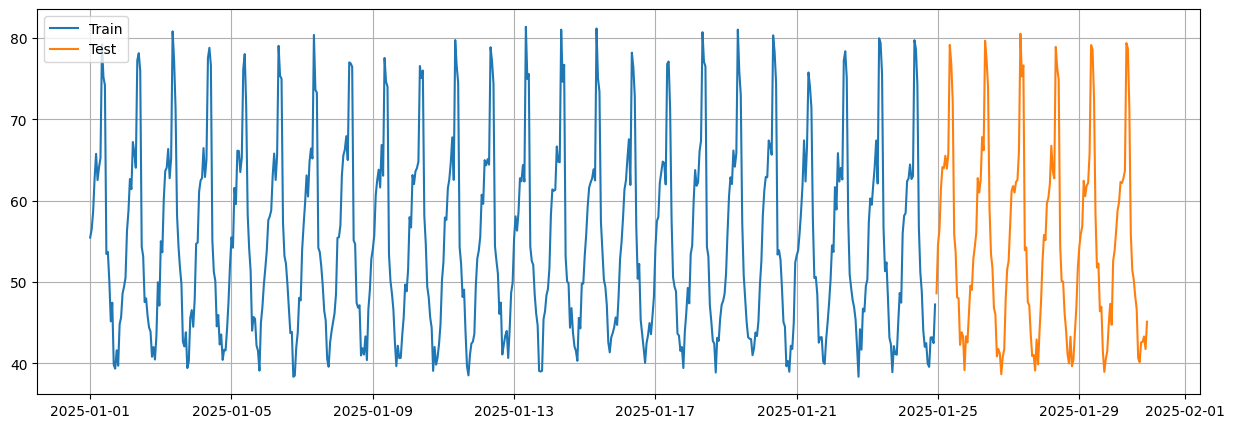

In [81]:
# ── Visualización train y test ────────────────────────────────────────────────
plt.figure(figsize=(15, 5))
plt.plot(train["consumo"], label="Train")
plt.plot(test["consumo"],  label="Test")
plt.legend()
plt.grid()
plt.show()

### p,d,q 
- p: ¿Cuántas horas atrás miro las ventas reales? --> Miro las 2 horas pasadas
- d: ¿Resto las ventas para quitar la tendencia? --> 0 = no hace falta, 1 = sí
- q: ¿Cuántas horas atrás miro mis errores pasados? --> Corrijo con los errores de hace 1h

### P,D,Q 
- P: ¿Miro las ventas de días anteriores? --> 1 = miro las de ayer
- D: ¿Resto el ciclo diario? --> 1 = sí, para eliminar el "sube-baja" del día
- Q: ¿Corrijo con errores de días anteriores? --> 1 = sí, uso el error de ayer

- s: ¿Cada cuánto se repite el ciclo? --> 24 horas = 1 día

### El modelo SARIMAX funciona bien cuando es estacionaria. Para eso hay que quitarle la tendencia. 
- ¿Cómo quitamos la tendencia? Febrero - Enero = +2 | Marzo   - Febrero = +2 | Abril   - Marzo   = +2 --> Esto se llama DIFERENCIAR
- d=1 --> es aplicar una resta, d=2 --> aplicamos dos restas (caso raro)

In [82]:
# ── Test de estacionariedad (Dickey-Fuller) ───────────────────────────────────
resultado = adfuller(train["consumo"])

print("H0: la serie no es estacionaria")
print(f"ADF:     {resultado[0]:.4f}")
print(f"p-valor: {resultado[1]:.4f}")

if resultado[1] >= 0.05:
    print("→ La serie NO es estacionaria — necesario diferenciar (d ≥ 1)")
else:
    print("→ La serie ES estacionaria")

H0: la serie no es estacionaria
ADF:     -20.0618
p-valor: 0.0000
→ La serie ES estacionaria


- Estacionariedad completa (Cuanto más negativo, más se evidencia la estacionariedad)
- p-valor < 0.5 : probabilidad 0 de equivocarse --> d = 0
- El consumo electrico no tiene tendencia --> Va de valles nocturnos a picos diurnos
- D = 1   →  Restas el ciclo diario para que el modelo se centre en lo demás

### Visualización de la función de autocorrelación ACF

##### ¿Cuánto se parece lo que pasa AHORA a lo que pasó HACE X horas?


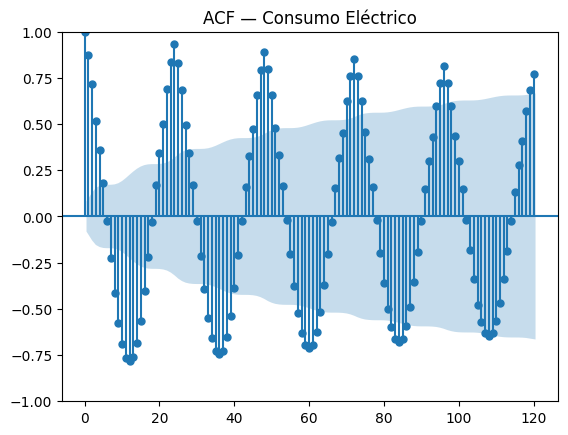

In [83]:
# ── ACF → detectamos q ───────────────────────────────────────────────────────

plot_acf(train["consumo"], lags=120)
plt.title("ACF — Consumo Eléctrico")
plt.show()

- Solo el lag 1 sobresale, resto dentro --> q = 1
- Lags 1 y 2 sobresalen, resto dentro --> q = 2
- Decae poco a poco --> q = 0

- Picos en lag 24 y 48 → hay estacionalidad diaria → Q = 1 | El consumo de ahora se parece mucho al de hace 24 horas. 

### Visualización de la función de autocorrelación PACF

##### ¿Cuánto influye HACE X HORAS DIRECTAMENTE, sin contar las horas intermedias?

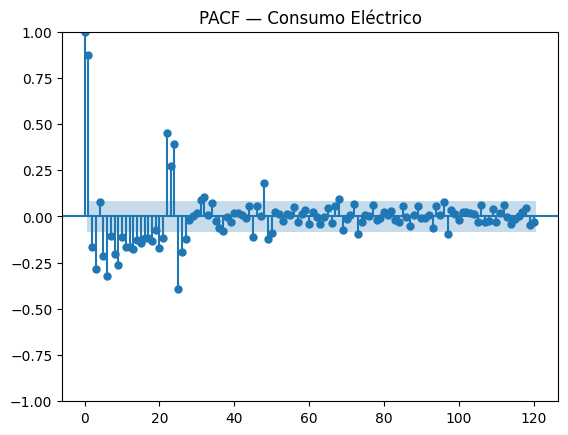

In [84]:
# ── PACF → detectamos p ──────────────────────────────────────────────────────
plot_pacf(train["consumo"], lags=120)
plt.title("PACF — Consumo Eléctrico")
plt.show()



- Corte limpio tras el lag 1 → p = 1
- Pico en lag 24 → hay componente AR estacional → P = 1 | El consumo de hace 24 horas influye directamente en el consumo de ahora. 

- SARIMA(1, 0, 1)(1, 1, 1, 24)

## Modelo SARIMAX

- p | PACF | 1 | Corte limpio tras lag 1
- d | ADF  | 0 | p = 0.00, sin tendencia
- q | ACF  | 1 | Decaimiento gradual
- P | PACF lag 24 | 1 | Pico directo en el lag 24
- D | ciclo diario| 1 | elimina el sube/baja diario
- Q | ACF lag 24 | 1 | Eeco fuerte en lag 24
- s ---> ciclo diario de 24 horas

### d y D  →  el semáforo (ADF)
### q y Q  →  el eco (ACF)
### p y P  →  la influencia directa (rumor) (PACF)
### s      →  el sentido común (¿cada cuánto se repite el ciclo?)

#### "El modelo predice el consumo eléctrico hora a hora basándose en 3 pilares: lo que ocurrió hace una hora, lo que ocurrió ayer a la misma hora, y la corrección de los errores que cometimos ayer. Con eso conseguimos un error medio inferior al 3%, suficiente para optimizar la contratación de potencia."



In [85]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

- Tendencia: cuando siempre crece (analogia con crecimiento de un niño)
- Estacionaria: no crece, se mantiene estable (analogia con una persona adulta)

In [93]:
modelo = SARIMAX(
    train["consumo"],
    order=(1,0,0), # Parte no estacional (los datos de hace unas horas) Pistas de hace poco
    seasonal_order=(1,0,1,24), # Parte estacional (lo que hiciste ayer a la misma hora) Pistsas de ayer mismo
    enforce_stationarity=False,
    enforce_invertibility=False
)

modelo = modelo.fit()

c:\Users\borja\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\borja\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [94]:
print(modelo.summary())

                                      SARIMAX Results                                       
Dep. Variable:                              consumo   No. Observations:                  575
Model:             SARIMAX(1, 0, 0)x(1, 0, [1], 24)   Log Likelihood               -1118.869
Date:                              Tue, 07 Jul 2026   AIC                           2245.738
Time:                                      12:23:19   BIC                           2262.978
Sample:                                  01-01-2025   HQIC                          2252.475
                                       - 01-24-2025                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0139      0.042     -0.329      0.742      -0.097       0.069
ar.S.L24       0.99

#### SARIMAX(1, 0, 1)x(1, 1, 1, 24)
####       │  │  │   │  │  │  │
####       │  │  │   │  │  │  └── ciclo de 24 horas
####       │  │  │   │  │  └───── corregir con el error de hace 24h
####       │  │  │   │  └──────── quitar el ciclo diario
####       │  │  │   └─────────── mirar el consumo de hace 24h
####       │  │  └─────────────── corregir con el error de la última hora
####       │  └────────────────── no quitar tendencia (ya es estacionaria)
####       └───────────────────── mirar el consumo de la última hora

- AIC  → Le da importancia al rendimiento
- BIC  → Le da importancia a la sencillez (menos piezas = mejor)
- HQIC → Un equilibrio entre los dos

- Menor AIC / BIC / HQIC  →  Mejor modelo

- Solo tienen sentido comparados con OTRO modelo.
- Un AIC de 2128 solo... no dice nada.
- Un AIC de 2128 vs 2200 → el primero es mejor.

### De los 5 solo nos vamos a quedar con 2:
- ma.S.L24 = -1.0191 (p = 0.000) -->   El MA estacional. Corrige la predicción con el error cometido hace 24 horas.
###### Si ayer a esta hora el modelo se equivocó por +5 kWh, hoy a esta hora descuento aproximadamente esos 5 kWh.
- sigma2 = 2.8917 (p = 0.000) --> La varianza residual — mide cuánto oscilan los errores del modelo.
###### √2.8917 ≈ 1.70 kWh de desviación estándar por hora. Coincide casi exactamente con el RMSE = 1.71 que obtuviste sobre test. Buena señal

### Explicación de los TEST

- **Ljung-Box** → p = 0.61 | ¿Los errores del modelo tienen algún patrón oculto?
- p > 0.05  →  Sin patrones → residuos limpios → ✅ | p ≤ 0.05  →  Con patrones → el modelo se dejó algo → ❌
- **Jarque-Bera** → p = 0.00 | ¿Los errores siguen una campana de Gauss (distribución normal)? 
- p > 0.05  →  Sí, son normales → intervalos de confianza fiables | p ≤ 0.05  →  No lo son → intervalos aproximados, no exactos
- **Heteroskedasticity** → p = 0.74 | ¿La magnitud del error cambia con el tiempo?
- p > 0.05  →  Error estable → varianza constante → ✅ | p ≤ 0.05  →  Error crece o decrece → problema
- **Skew**  -0.07   →  simetría casi perfecta ✅ (mide asimetría. Cerca de 0 es perfecto.)
- **Kurtosis** 2.03   →  colas ligeras (referencia normal = 3.0) ⚠️ (mide cómo son las colas de la distribución. Por debajo de 3 significa colas más ligeras)

In [95]:
# Predicciones para el conjunto test

pred = modelo.get_forecast(
    steps=len(test)
)

pred_media = pred.predicted_mean
pred_ic = pred.conf_int()

In [96]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae=mean_absolute_error(
    test["consumo"],
    pred_media
)

rmse = np.sqrt(
    mean_squared_error(
    test["consumo"],
    pred_media
    )
)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 1.46
RMSE: 1.70


- MAE: 1.46 kWh --> Error medio por hora
- RMSE: 1.71 kWh --> Penaliza los picos de erro

In [97]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Cálculo
mae  = mean_absolute_error(test["consumo"], pred_media)
rmse = np.sqrt(mean_squared_error(test["consumo"], pred_media))

# Métricas contextuales que dan la historia completa
consumo_medio = test["consumo"].mean()
mape          = np.mean(np.abs((test["consumo"] - pred_media) / test["consumo"])) * 100
ratio         = rmse / mae

print(f"MAE:           {mae:.2f} kWh")
print(f"RMSE:          {rmse:.2f} kWh")
print(f"Consumo medio: {consumo_medio:.2f} kWh")
print(f"Error rel.:    {(mae/consumo_medio)*100:.2f} %")
print(f"MAPE:          {mape:.2f} %")
print(f"Ratio RMSE/MAE:{ratio:.2f}")

MAE:           1.46 kWh
RMSE:          1.70 kWh
Consumo medio: 54.78 kWh
Error rel.:    2.67 %
MAPE:          2.79 %
Ratio RMSE/MAE:1.16


- MAE --> ¿Cuánto me equivoco de media, en unidades reales? | 1.46 kWh
- RMSE --> ¿Los errores grandes son un problema? | 1.71 kWh
- Consumo medio --> ¿Cuál es la escala del problema? | 54.78 kWh
- Error relativo --> ¿El error es grande respecto al consumo? | 2.66%
- MAPE --> ¿Y respecto a cada hora individualmente? | 2.81%
- Ratio RMSE/MAE --> ¿Los errores son consistentes o hay outliers? | 1.17


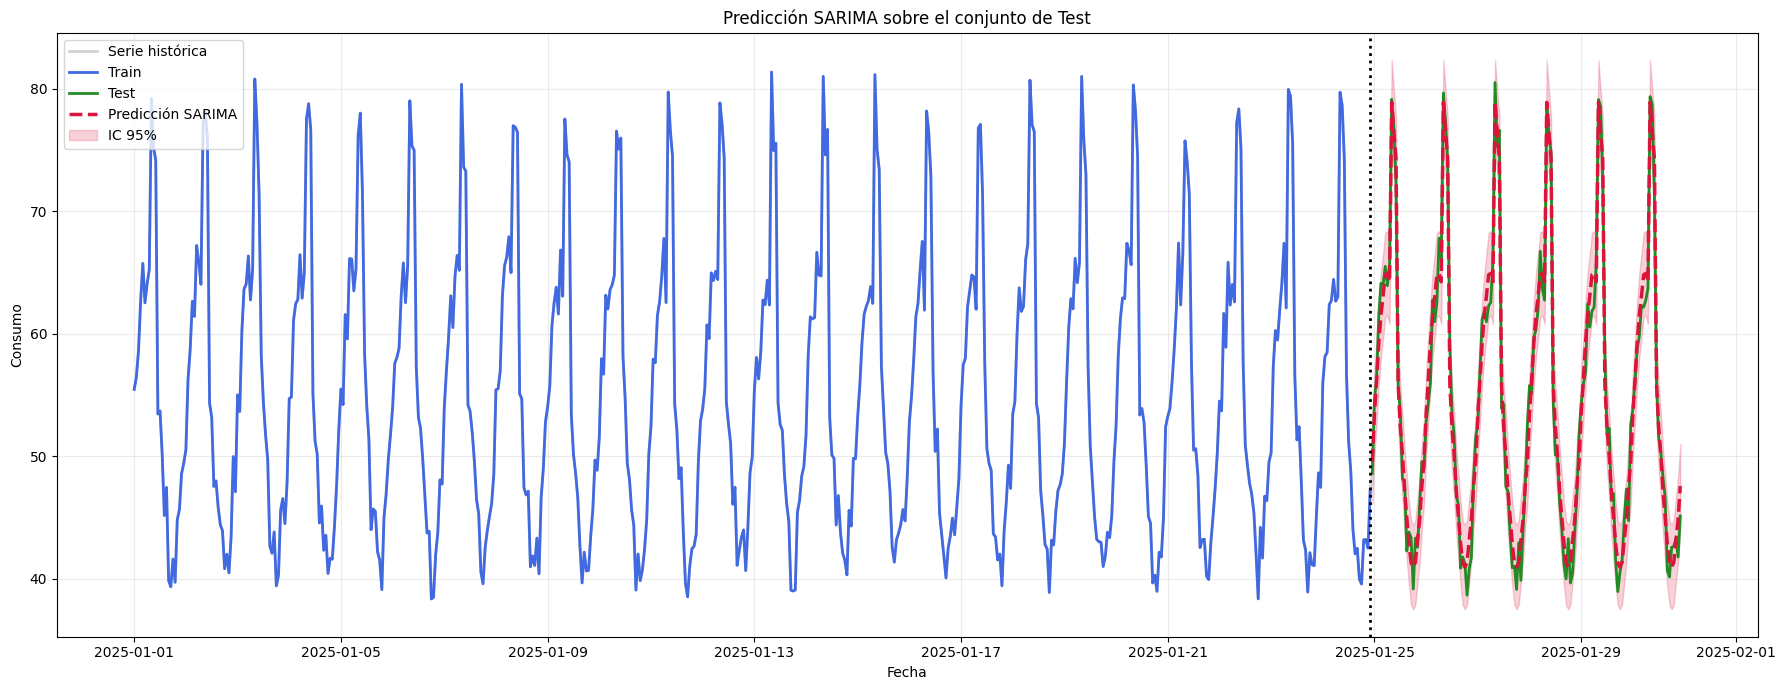

In [91]:
plt.figure(figsize=(18, 7))

# Histórico
plt.plot(
    data.index,
    data["consumo"],
    color="lightgray",
    linewidth=2,
    label="Serie histórica"
)

# Train
plt.plot(
    train.index,
    train["consumo"],
    color="royalblue",
    linewidth=2,
    label="Train"
)

# Test
plt.plot(
    test.index,
    test["consumo"],
    color="forestgreen",
    linewidth=2,
    label="Test"
)

# Predicción
plt.plot(
    test.index,
    pred_media,
    color="crimson",
    linewidth=2.5,
    linestyle="--",
    label="Predicción SARIMA"
)

# Intervalo de confianza
plt.fill_between(
    test.index,
    pred_ic.iloc[:, 0],
    pred_ic.iloc[:, 1],
    color="crimson",
    alpha=0.20,
    label="IC 95%"
)

# Línea de separación
plt.axvline(
    train.index[-1],
    color="black",
    linestyle=":",
    linewidth=2
)

plt.title("Predicción SARIMA sobre el conjunto de Test")
plt.xlabel("Fecha")
plt.ylabel("Consumo")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

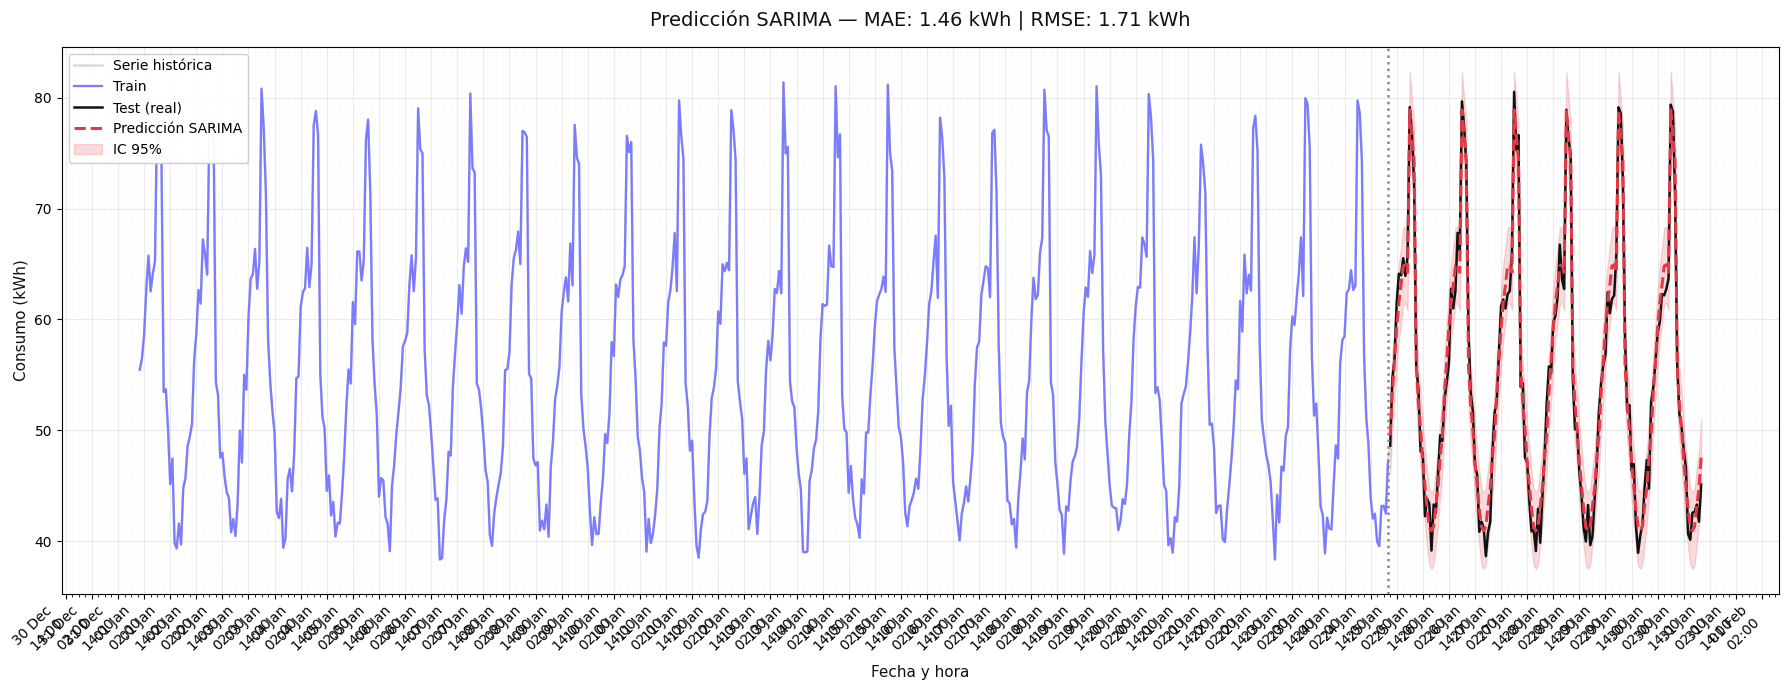

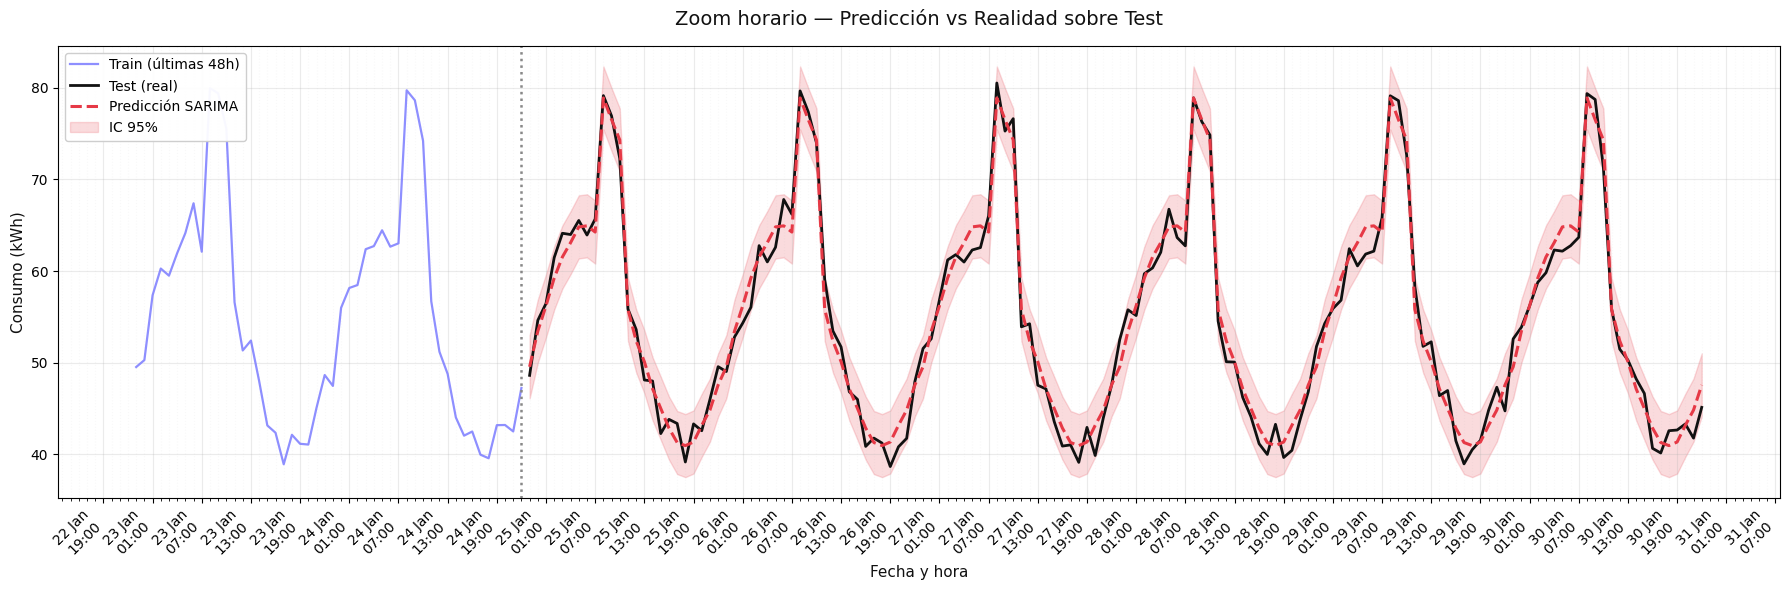

In [92]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ═══════════════════════════════════════════════════════════════════════════
#  VISTA 1 — Plot completo con eje X horario (cada 12h)
# ═══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(18, 7))

# Histórico
ax.plot(
    data.index, data["consumo"],
    color="#d9d9d9", linewidth=1.8,
    label="Serie histórica"
)

# Train
ax.plot(
    train.index, train["consumo"],
    color="#7a7bff", linewidth=1.6,
    label="Train"
)

# Test
ax.plot(
    test.index, test["consumo"],
    color="#111", linewidth=1.8,
    label="Test (real)"
)

# Predicción
ax.plot(
    test.index, pred_media,
    color="#e63946", linewidth=2.2, linestyle="--",
    label="Predicción SARIMA"
)

# Intervalo de confianza
ax.fill_between(
    test.index,
    pred_ic.iloc[:, 0], pred_ic.iloc[:, 1],
    color="#e63946", alpha=0.18,
    label="IC 95%"
)

# Línea de separación train/test
ax.axvline(
    train.index[-1],
    color="#888", linestyle=":", linewidth=1.8
)

# ── Configuración del eje X en formato horario ────────────────────────────
ax.xaxis.set_major_locator(mdates.HourLocator(interval=12))        # cada 12h
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b\n%H:%M"))
ax.xaxis.set_minor_locator(mdates.HourLocator(interval=3))          # rejilla cada 3h

ax.set_title(
    f"Predicción SARIMA — MAE: {mae:.2f} kWh | RMSE: {rmse:.2f} kWh",
    fontsize=14, color="#111", pad=15
)
ax.set_xlabel("Fecha y hora", fontsize=11, color="#111")
ax.set_ylabel("Consumo (kWh)", fontsize=11, color="#111")
ax.grid(alpha=0.25, which="major")
ax.grid(alpha=0.10, which="minor", linestyle=":")
ax.legend(loc="upper left", frameon=True, framealpha=0.95)

fig.autofmt_xdate(rotation=45)
plt.tight_layout()
plt.show()


# ═══════════════════════════════════════════════════════════════════════════
#  VISTA 2 — Zoom horario al conjunto Test (cada 6h)
#  Aquí es donde de verdad se aprecia el ajuste hora a hora
# ═══════════════════════════════════════════════════════════════════════════
ventana_train_visible = 48   # últimas 48h de train (2 días) para contexto
inicio = train.index[-ventana_train_visible]

fig, ax = plt.subplots(figsize=(18, 6))

# Contexto: últimas 48h de train
ax.plot(
    train.loc[inicio:].index, train.loc[inicio:, "consumo"],
    color="#7a7bff", linewidth=1.6, alpha=0.85,
    label=f"Train (últimas {ventana_train_visible}h)"
)

# Test real
ax.plot(
    test.index, test["consumo"],
    color="#111", linewidth=2.0,
    label="Test (real)"
)

# Predicción
ax.plot(
    test.index, pred_media,
    color="#e63946", linewidth=2.2, linestyle="--",
    label="Predicción SARIMA"
)

# Banda IC 95%
ax.fill_between(
    test.index,
    pred_ic.iloc[:, 0], pred_ic.iloc[:, 1],
    color="#e63946", alpha=0.18,
    label="IC 95%"
)

# Línea de separación
ax.axvline(
    train.index[-1],
    color="#888", linestyle=":", linewidth=1.8
)

# ── Eje X con horas explícitas cada 6h ────────────────────────────────────
ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b\n%H:%M"))
ax.xaxis.set_minor_locator(mdates.HourLocator(interval=1))          # rejilla cada hora

ax.set_title(
    "Zoom horario — Predicción vs Realidad sobre Test",
    fontsize=14, color="#111", pad=15
)
ax.set_xlabel("Fecha y hora", fontsize=11, color="#111")
ax.set_ylabel("Consumo (kWh)", fontsize=11, color="#111")
ax.grid(alpha=0.25, which="major")
ax.grid(alpha=0.08, which="minor", linestyle=":")
ax.legend(loc="upper left", frameon=True, framealpha=0.95)

fig.autofmt_xdate(rotation=45)
plt.tight_layout()
plt.show()